In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

from IPython.display import display

import matplotlib.pyplot as plt
REPO_DIR = os.environ['REPO_DIR']
DATA_DIR = os.environ['DATA_DIR']
sys.path.append(REPO_DIR)

from src.steering_utils import read_top_k_images

from packages.overcomplete.visualization.top_concepts import overlay_heatmaps_to_images
from utils.utils import numpy_to_pil

yaml_file = os.path.join(REPO_DIR, 'config', 'dataset_config.yaml')

In [2]:
from utils.utils import list_features

top_k_images_dir = f"{DATA_DIR}/input_features_explainer/google_gemma-3-4b-it_AutoEncoderTopK/enc_res_out_layer_16_8192_22191080/top_k_images/ILSVRC_imagenet-1k_mean_test_10_50000"
#top_k_images_dir = f"{DATA_DIR}/input_features_explainer/facebook_dinov2-small_AutoEncoderTopK/enc_res_out_layer_8_128_13216850/top_k_images/ILSVRC_imagenet-1k_mean_validation_10_1000"

latents = list_features(Path(top_k_images_dir))

### Read Top K Images with Heatmaps

In [4]:
from dictionary_learning.utils import load_dataset_from_yaml
dataset = "ILSVRC/imagenet-1k"
top_k_images_split = 'test' # Use the same split as the top k images!!!
dataset = "ILSVRC/imagenet-1k"
# dataset = "ILSVRC/imagenet-1k"
# top_k_images_split = 'validation'
# dataset = "ILSVRC/imagenet-1k"
ds, _ = load_dataset_from_yaml(dataset, top_k_images_split)

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/24 [00:00<?, ?it/s]

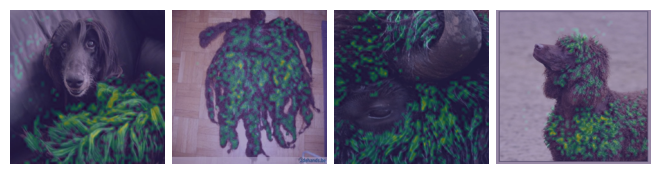

In [9]:
latent_id = 15
top_k = 4

if top_k == 5:
    fig = plt.figure(figsize=(10, 2), facecolor='none')

latent = f"{latent_id}"

output = read_top_k_images(ds, latent, top_k_images_dir, k=top_k, top_k_random_sample=False, partition=None)
images = output['images']
heatmaps = output['heatmaps']

overlayed_heatmaps = overlay_heatmaps_to_images(images, heatmaps, alpha=0.45)
overlayed_heatmaps = [numpy_to_pil(heatmap) for heatmap in overlayed_heatmaps if heatmap is not None]
for i in range(top_k):
    # Create a grid layout based on top_k value
    if top_k == 4:
        plt.subplot(1, 4, i + 1)
    if top_k==20:
        plt.subplot(4, 5, i + 1)
    elif top_k==5:
        plt.subplot(1, 5, i+1)
    elif top_k==10:
        plt.subplot(2, 5, i+1)
    elif top_k==3:
        plt.subplot(3, 1, i+1)

    # Resize the image to 224x224
    resized_heatmap = overlayed_heatmaps[i].resize((224, 224))
    overlayed_heatmaps[i] = resized_heatmap
    plt.imshow(overlayed_heatmaps[i])
    plt.axis('off')
    
    #plt.savefig('output.png', bbox_inches='tight', transparent=True)#, bbox_inches='tight', transparent=True

# Add these lines AFTER both loops
plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0, right=1, top=1, bottom=0)
plt.show()
plt.close()

In [ ]:
top_k = 5
idx = 0

for latent in latents[idx:idx+20]: #idx+1
    latent = latent.replace('latent_', '')
    if top_k == 5:
        fig = plt.figure(figsize=(10, 2), facecolor='none')
    plt.suptitle(f"{latent}", fontsize=16)
    output = read_top_k_images(ds, latent, top_k_images_dir, k=top_k, top_k_random_sample=True)
    images = output['images']
    heatmaps = output['heatmaps']

    overlayed_heatmaps = overlay_heatmaps_to_images(images, heatmaps, alpha=0.35)
    overlayed_heatmaps = [numpy_to_pil(heatmap) for heatmap in overlayed_heatmaps if heatmap is not None]
    for i in range(top_k):
        # Create a grid layout based on top_k value
        if top_k==20:
            plt.subplot(4, 5, i + 1)
        elif top_k==5:
            plt.subplot(1, 5, i+1)
        elif top_k==3:
            plt.subplot(3, 1, i+1)
        elif top_k == 12:
            plt.subplot(4, 3, i+1)
        else:
            raise ValueError(f"Unsupported top_k value: {top_k}.")

        # Resize the image to 224x224
        resized_heatmap = overlayed_heatmaps[i].resize((224, 224))
        overlayed_heatmaps[i] = resized_heatmap
        plt.imshow(overlayed_heatmaps[i])
        plt.axis('off')
    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0, right=1, top=1, bottom=0)

    # Add these lines AFTER both loops
    plt.tight_layout()
    plt.show()
    plt.close()
